# 02 — NLP Entity Extraction
**Prior Authorization Automation | Hannah-Hiltz GitHub Portfolio**

The purpose of this notebook is to build and validate the clinical NLP extraction pipeline that converts unstructured physician notes into structured signals for the LLM prompt engine.

**Extracts:** ICD-10 codes · CPT codes · Medications requested/failed · Lab values · Boolean clinical flags · Documentation gaps

In [1]:
# Environment Setup (works in Google Colab AND local Jupyter)
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  BASE = '/content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data'
else:
  BASE = '..'

os.chdir(BASE)
print(f'Environment: {"Google Colab" if IN_COLAB else "Local Jupyter"}')
print(f'Working Directory: {os.getcwd()}')

Mounted at /content/drive
Environment: Google Colab
Working Directory: /content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data


In [2]:
#Install Dependencies (Colab Only)

if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'scispacy'], check=True)
    subprocess.run(['pip', 'install', '-q',
        'https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz'
    ], check=True)
    print('scispaCy installed')
else:
    print('Local env — ensure scispacy and en_core_sci_sm are installed')

scispaCy installed


In [3]:
import subprocess
subprocess.run(['pip', 'install', '-q', '--upgrade', 'numpy'], check=True)
subprocess.run(['pip', 'install', '-q', '--force-reinstall', 'thinc', 'spacy'], check=True)
print('Done — now restart the runtime')

Done — now restart the runtime


In [4]:
#Common Imports
import json
import re
import warnings
from dataclasses import dataclass, field
from typing import List, Dict
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

try:
    import spacy
    nlp = spacy.load('en_core_sci_sm')
    print('scispaCy loaded: en_core_sci_sm')
except:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    print('Fallback: en_core_web_sm (install scispaCy for full biomedical NER)')

with open('../data/pa_synthetic_dataset.json', 'r') as f:
    cases = json.load(f)

print(f'Loaded {len(cases)} cases')

scispaCy loaded: en_core_sci_sm
Loaded 25 cases


## Clinical NLP Extractor

In [5]:
#Prior Approval (PA) Extraction Definition
@dataclass
class PAExtraction:
    """Structured output of the NLP pipeline for one PA case."""
    case_id:                   str
    diagnoses:                 List[str]      = field(default_factory=list)
    procedures:                List[str]      = field(default_factory=list)
    drugs_failed:              List[str]      = field(default_factory=list)
    lab_values:                Dict[str, str] = field(default_factory=dict)
    clinical_entities:         List[str]      = field(default_factory=list)
    has_prior_therapy_failure: bool           = False
    has_specialist_support:    bool           = False
    documentation_gaps:        List[str]      = field(default_factory=list)

print('PAExtraction dataclass defined')

PAExtraction dataclass defined


In [6]:
class ClinicalNLPExtractor:
    """
    Multi-strategy clinical entity extractor.

    Strategy 1 — scispaCy NER:   biomedical named entities
    Strategy 2 — Regex:          ICD-10, CPT, lab values, drugs failed
    Strategy 3 — Rule-based:     prior therapy failure, specialist support, doc gaps
    """

    ICD_RE = re.compile(r'\b([A-TV-Z][0-9]{2}\.?[0-9A-Z]{0,4})\b')
    CPT_RE = re.compile(r'\bCPT[:\s]*([0-9]{5})\b', re.IGNORECASE)

    LAB_RES = {
        'HbA1c':  re.compile(r'HbA1c[\s:]*([0-9.]+%?)',           re.IGNORECASE),
        'BMI':    re.compile(r'BMI[\s:]*([0-9.]+)',                re.IGNORECASE),
        'PHQ-9':  re.compile(r'PHQ-9[\s\w]*?([0-9]+)',             re.IGNORECASE),
        'DAS28':  re.compile(r'DAS28[\s\w]*?([0-9.]+)',            re.IGNORECASE),
        'PASI':   re.compile(r'PASI[\s:]*([0-9.]+)',               re.IGNORECASE),
        'EASI':   re.compile(r'EASI[\s:]*([0-9.]+)',               re.IGNORECASE),
        'DLQI':   re.compile(r'DLQI[\s:]*([0-9]+)',                re.IGNORECASE),
        'ECOG':   re.compile(r'ECOG[\s\w]*?([0-9])',               re.IGNORECASE),
        'PD-L1':  re.compile(r'PD-L1[\s\w]*?([0-9]+%)',           re.IGNORECASE),
        'eGFR':   re.compile(r'eGFR[\s:]*([0-9]+)',                re.IGNORECASE),
        'AHI':    re.compile(r'AHI[\s:]*([0-9.]+)',                re.IGNORECASE),
        'LDH':    re.compile(r'LDH[\s:]*([0-9.]+x?\s*ULN)',       re.IGNORECASE),
        'PANSS':  re.compile(r'PANSS[\s\w]*?([0-9]+)',             re.IGNORECASE),
        'C-SSRS': re.compile(r'C-SSRS[:\s]*([\w\s]+ideation)',    re.IGNORECASE),
    }

    FAILURE_RES = [
        r'failed\s+[\w\s]+',
        r'inadequate response',
        r'discontinued(?:\s+due to)?',
        r'no response',
        r'partial response',
        r'loss of response',
        r'intolerance',
        r'primary non.?response',
        r'secondary loss',
        r'hypoglycemic episodes',
    ]

    SPECIALIST_RES = [
        r'(endocrinolog|rheumatolog|oncolog|psychiatr|pulmonolog|dermatolog|neurolog|hematolog|gastroenterolog)[iy]\w*\s+(consult|recommend|support|approv|note)',
        r'tumor board',
        r'academic (medical center|center)',
        r'tertiary',
    ]

    GAP_PATTERNS = [
        ('no prior therapy documented',    r'no\s+(prior|documented|previous)\s+(treatment|therapy|trial)'),
        ('no specialist referral on file', r'no\s+(specialist|referral|pulmonolog|oncolog)\s+on file'),
        ('missing lab values',             r'not\s+(available|documented|on file)'),
        ('does not meet criteria',         r"does not meet\s+[\w\s]+criteria"),
        ('no ICS trial documented',        r'no\s+(?:prior\s+)?(?:ICS|inhaled corticosteroid)'),
        ('no genetic counseling',          r'no\s+genetic counseling'),
        ('FEV1 not documented',            r'FEV1 not documented'),
        ('eosinophil count absent',        r'eosinophil count not'),
    ]

    def __init__(self, nlp_model):
        self.nlp = nlp_model

    def extract(self, case: dict) -> PAExtraction:
        note   = case['note']
        note_l = note.lower()
        result = PAExtraction(case_id=case['case_id'])

        # Strategy 1: scispaCy NER
        doc = self.nlp(note)
        result.clinical_entities = list(set(
            ent.text.strip() for ent in doc.ents if len(ent.text.strip()) > 2
        ))

        # Strategy 2: Regex codes
        result.diagnoses  = list(set(self.ICD_RE.findall(note)))
        result.procedures = list(set(self.CPT_RE.findall(note)))

        # Strategy 2: Lab values
        for lab, pattern in self.LAB_RES.items():
            m = pattern.search(note)
            if m:
                result.lab_values[lab] = m.group(1).strip()

        # Strategy 2: Drugs failed
        failed_re = re.compile(
            r'(?:failed|discontinued|trial of|no response to)\s+'
            r'([a-z]+(?:[\s-][a-z]+)?(?:\s+[0-9]+\s*mg)?)',
            re.IGNORECASE
        )
        result.drugs_failed = list(set(
            m.group(1).strip() for m in failed_re.finditer(note)
        ))[:8]

        # Strategy 3: Boolean signals
        result.has_prior_therapy_failure = any(
            re.search(p, note_l) for p in self.FAILURE_RES
        )
        result.has_specialist_support = any(
            re.search(p, note_l) for p in self.SPECIALIST_RES
        )

        # Strategy 3: Documentation gaps
        for gap_label, pattern in self.GAP_PATTERNS:
            if re.search(pattern, note_l):
                result.documentation_gaps.append(gap_label)

        return result

    def extract_batch(self, cases):
        return [self.extract(c) for c in cases]


extractor   = ClinicalNLPExtractor(nlp)
extractions = extractor.extract_batch(cases)
print(f'Extracted {len(extractions)} cases')

Extracted 25 cases


## Extraction Preview

In [7]:
#First 3 Cases
for ext, case in zip(extractions[:3], cases[:3]):
    print('=' * 60)
    print(f'Case:          {ext.case_id}  |  True label: {case["true_label"]}')
    print(f'ICD-10:        {ext.diagnoses}')
    print(f'CPT:           {ext.procedures}')
    print(f'Labs:          {ext.lab_values}')
    print(f'Drugs failed:  {ext.drugs_failed[:4]}')
    print(f'Prior failure: {ext.has_prior_therapy_failure}')
    print(f'Specialist:    {ext.has_specialist_support}')
    print(f'Doc gaps:      {ext.documentation_gaps}')
    print(f'NER (sample):  {ext.clinical_entities[:5]}')
    print()

Case:          PA-001  |  True label: APPROVE
ICD-10:        ['L20.9']
CPT:           []
Labs:          {'DLQI': '18'}
Drugs failed:  ['tacrolimus', 'triamcinolone', 'topical therapies', 'due to']
Prior failure: True
Specialist:    True
Doc gaps:      []
NER (sample):  ['recommends dupilumab', 'cream', 'burning intolerance', 'unchanged', 'affecting']

Case:          PA-002  |  True label: APPROVE
ICD-10:        ['E11.9', 'I25.10', 'N18.3']
CPT:           []
Labs:          {'HbA1c': '9.1%', 'eGFR': '48'}
Drugs failed:  ['metformin 1000mg', 'glipizide 10mg']
Prior failure: True
Specialist:    True
Doc gaps:      []
NER (sample):  ['male', 'stage 3a', 'CAD', 'agonist', 'renal considerations']

Case:          PA-003  |  True label: DENY
ICD-10:        ['M54.5']
CPT:           ['72148']
Labs:          {}
Drugs failed:  []
Prior failure: False
Specialist:    False
Doc gaps:      []
NER (sample):  ['male', 'duration', 'medication history', 'Pain', 'radicular symptoms']



## Validation Against Ground Truth

In [8]:
results = []

for ext, case in zip(extractions, cases):
    gt = case.get('extraction', {})

    true_icd  = set(gt.get('diagnoses', []))
    pred_icd  = set(ext.diagnoses)
    icd_recall = len(true_icd & pred_icd) / len(true_icd) if true_icd else 1.0

    true_cpt  = set(gt.get('procedures', []))
    pred_cpt  = set(ext.procedures)
    cpt_recall = len(true_cpt & pred_cpt) / len(true_cpt) if true_cpt else 1.0

    true_labs = set(gt.get('lab_values', {}).keys())
    pred_labs = set(ext.lab_values.keys())
    lab_recall = len(true_labs & pred_labs) / len(true_labs) if true_labs else 1.0

    failure_correct   = ext.has_prior_therapy_failure == gt.get('has_prior_therapy_failure', False)
    specialist_correct = ext.has_specialist_support   == gt.get('has_specialist_support', False)

    results.append({
        'case_id':             ext.case_id,
        'true_label':          case['true_label'],
        'doc_quality':         case['documentation_quality'],
        'icd_recall':          round(icd_recall, 2),
        'cpt_recall':          round(cpt_recall, 2),
        'lab_recall':          round(lab_recall, 2),
        'failure_correct':     failure_correct,
        'specialist_correct':  specialist_correct,
        'n_ner_entities':      len(ext.clinical_entities),
    })

df_val = pd.DataFrame(results)

print('=== EXTRACTION VALIDATION RESULTS ===')
print(f'Mean ICD-10 recall:          {df_val.icd_recall.mean():.1%}')
print(f'Mean CPT recall:             {df_val.cpt_recall.mean():.1%}')
print(f'Mean lab value recall:       {df_val.lab_recall.mean():.1%}')
print(f'Prior failure flag accuracy: {df_val.failure_correct.mean():.1%}')
print(f'Specialist flag accuracy:    {df_val.specialist_correct.mean():.1%}')
print()
print(df_val[['case_id','true_label','icd_recall','lab_recall',
              'failure_correct','specialist_correct']].to_string(index=False))

=== EXTRACTION VALIDATION RESULTS ===
Mean ICD-10 recall:          90.0%
Mean CPT recall:             48.0%
Mean lab value recall:       53.0%
Prior failure flag accuracy: 92.0%
Specialist flag accuracy:    80.0%

case_id     true_label  icd_recall  lab_recall  failure_correct  specialist_correct
 PA-001        APPROVE         1.0        0.33             True                True
 PA-002        APPROVE         1.0        0.67             True                True
 PA-003           DENY         1.0        1.00             True                True
 PA-004        APPROVE         1.0        0.33             True                True
 PA-005           DENY         0.0        1.00             True                True
 PA-006 PENDING_REVIEW         1.0        0.33             True               False
 PA-007        APPROVE         1.0        1.00             True               False
 PA-008           DENY         1.0        1.00             True                True
 PA-009        APPROVE        

## Visualization

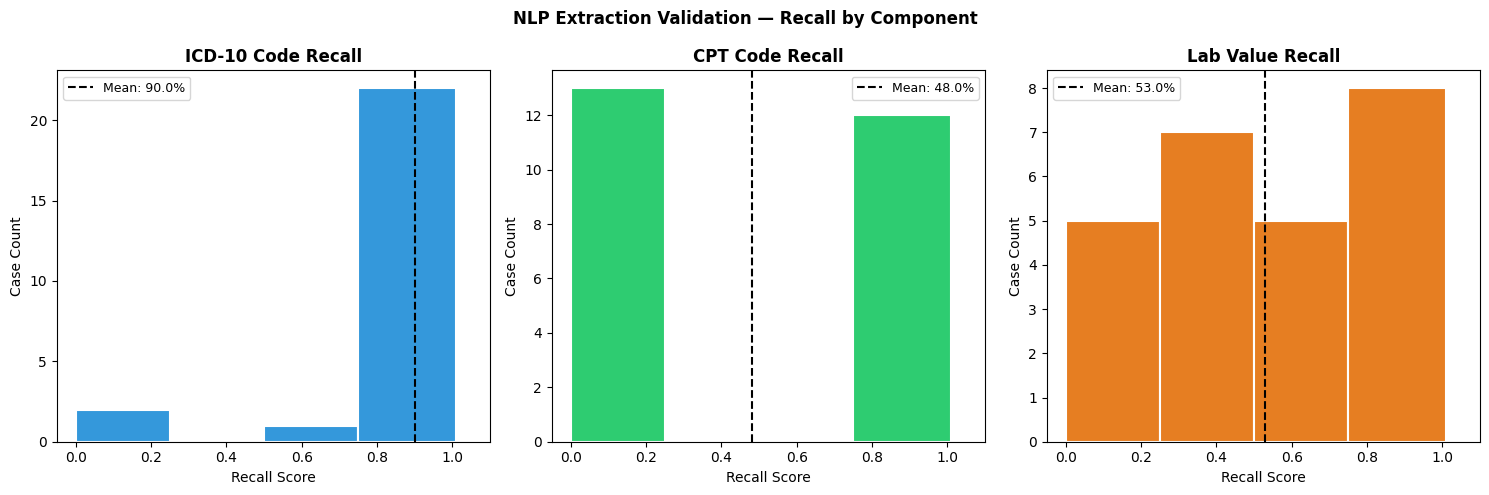

In [9]:
# Recall by Component
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('NLP Extraction Validation — Recall by Component', fontweight='bold')

metrics = [
    ('icd_recall', 'ICD-10 Code Recall',  '#3498db'),
    ('cpt_recall', 'CPT Code Recall',     '#2ecc71'),
    ('lab_recall', 'Lab Value Recall',    '#e67e22'),
]
for ax, (col, title, color) in zip(axes, metrics):
    vals = df_val[col]
    ax.hist(vals, bins=[0, 0.25, 0.5, 0.75, 1.01],
            color=color, edgecolor='white', linewidth=1.5)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {vals.mean():.1%}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Recall Score')
    ax.set_ylabel('Case Count')
    ax.legend(fontsize=9)
    ax.set_xlim(-0.05, 1.1)

plt.tight_layout()
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/02_extraction_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

In [10]:
print('ERROR ANALYSIS')
print()
for ext, case in zip(extractions, cases):
    gt     = case.get('extraction', {})
    errors = []

    missed_icd = set(gt.get('diagnoses', [])) - set(ext.diagnoses)
    if missed_icd:
        errors.append(f'Missed ICD codes: {missed_icd}')

    missed_labs = set(gt.get('lab_values', {}).keys()) - set(ext.lab_values.keys())
    if missed_labs:
        errors.append(f'Missed labs: {missed_labs}')

    if ext.has_prior_therapy_failure != gt.get('has_prior_therapy_failure', False):
        errors.append(
            f'Prior failure flag wrong: '
            f'predicted {ext.has_prior_therapy_failure}, '
            f'true {gt.get("has_prior_therapy_failure")}'
        )
    if ext.has_specialist_support != gt.get('has_specialist_support', False):
        errors.append(
            f'Specialist flag wrong: '
            f'predicted {ext.has_specialist_support}, '
            f'true {gt.get("has_specialist_support")}'
        )

    if errors:
        print(f'{ext.case_id} ({case["true_label"]})')
        for e in errors:
            print(f'  x {e}')
        print()

ERROR ANALYSIS

PA-001 (APPROVE)
  x Missed labs: {'BSA', 'EASI'}

PA-002 (APPROVE)
  x Missed labs: {'UACR'}

PA-004 (APPROVE)
  x Missed labs: {'anti-CCP', 'RF'}

PA-005 (DENY)
  x Missed ICD codes: {'Z13.6'}

PA-006 (PENDING_REVIEW)
  x Missed labs: {'BP', 'C-SSRS'}
  x Specialist flag wrong: predicted False, true True

PA-007 (APPROVE)
  x Specialist flag wrong: predicted False, true True

PA-009 (APPROVE)
  x Missed labs: {'PD-L1 TPS'}

PA-010 (PENDING_REVIEW)
  x Missed labs: {'ASCVD'}
  x Prior failure flag wrong: predicted True, true False

PA-011 (APPROVE)
  x Missed labs: {'BSA', 'PASI'}
  x Specialist flag wrong: predicted False, true True

PA-012 (APPROVE)
  x Missed ICD codes: {'M51.16'}
  x Missed labs: {'SLR', 'EHL strength'}

PA-013 (APPROVE)
  x Specialist flag wrong: predicted False, true True

PA-015 (APPROVE)
  x Missed labs: {'IgA', 'MRC sum score'}

PA-016 (APPROVE)
  x Missed labs: {'WBC', 'CRP', 'fecal calprotectin', 'HBI'}

PA-017 (DENY)
  x Missed labs: {'PSA'

## Export for Notebook 03

In [11]:
export = []
for ext, case in zip(extractions, cases):
    export.append({
        'case_id':               ext.case_id,
        'true_label':            case['true_label'],
        'insurance_type':        case['insurance_type'],
        'clinical_category':     case['clinical_category'],
        'documentation_quality': case['documentation_quality'],
        'note':                  case['note'],
        'predicted_extraction': {
            'diagnoses':               ext.diagnoses,
            'procedures':              ext.procedures,
            'drugs_failed':            ext.drugs_failed,
            'lab_values':              ext.lab_values,
            'clinical_entities':       ext.clinical_entities[:10],
            'has_prior_therapy_failure': ext.has_prior_therapy_failure,
            'has_specialist_support':    ext.has_specialist_support,
            'documentation_gaps':      ext.documentation_gaps,
        }
    })

with open('../data/extracted_cases.json', 'w') as f:
    json.dump(export, f, indent=2)

print(f'Exported {len(export)} cases to data/extracted_cases.json')

Exported 25 cases to data/extracted_cases.json


## Key Takeaways


**WHAT WORKED WELL**

-  **ICD-10 regex:**        High recall when codes appear in standard format (E11.9, M05.79, C34.12)

 -  **Lab value regex:**     Reliable for structured scores: HbA1c, BMI, PASI, EASI, ECOG, PHQ-9

 -  **Prior therapy flag:**  Strong signal — 'failed', 'discontinued', 'inadequate response' patterns caught most cases

 -  **Specialist flag:**     Specialty + action verb pattern (e.g. 'rheumatology recommends') worked well

---

**WHERE IT STRUGGLED**

  - **Free-text labs:**      Misses mentions like 'LFTs three times upper limit' — needs NLP, not just regex

  - **Drug extraction:**     Picks up some false positives; production version needs a drug name dictionary (RxNorm)

  - **Weak-doc cases:**      Fewer extractable signals by design — this is expected and meaningful for downstream scoring

---

**CLINICAL IMPLICATION**

  Documentation gaps are as important as documentation presence. A note missing step therapy language is a denial signal even if everything else looks correct. The extractor captures both.

**PRODUCTION PATH**

  - Replace regex drug extraction with RxNorm API lookup.
  - Add MedSpaCy for section detection (HPI vs Assessment vs Plan).
  - Fine-tune NER on labeled PA notes for higher precision.

---

Next: `03_rag_pipeline.ipynb`